# 05 Classification — AI Literacy Gap Risk Drivers

## Why this notebook exists

The previous notebooks established **how much** AI literacy gap risk each EU NUTS-1 region carries. The composite index (`03_index_construction.ipynb`) scores 87 regions across six structural vulnerability pillars; the clustering (`04_clustering.ipynb`) groups them into five risk profile types.

What neither of those steps answers is: **which of the six pillars is the strongest driver of high risk?**

That is the question this notebook addresses. We train a **logistic regression classifier** that predicts whether a region falls into the high-risk category based on its six raw pillar values. The model coefficients directly reveal which indicators most strongly separate high-risk regions from the rest — giving policymakers a clear answer on where intervention has the greatest leverage.

### Why logistic regression on raw pillar values?

The six pillars were selected in `02_EDA.ipynb` as the best available proxy indicators for structural AI literacy gap risk across Europe. In `03_index_construction.ipynb` they were normalised and combined into a composite score using PCA-derived weights. Here we deliberately work with the **raw, unnormalised values** — the original percentages as reported by Eurostat — so that the model learns independently from the index construction. This avoids circularity: the model is not recovering the weights we put in; it is discovering which indicators the data itself identifies as most predictive.

### The six pillars

| Column | Pillar | Direction |
|---|---|---|
| `digital_skills_pct` | P1 — Digital Skills | Lower % = higher risk |
| `poverty_social_exclusion_rate` | P2 — Poverty & Social Exclusion | Higher % = higher risk |
| `low_education_pct` | P3 — Low Educational Attainment | Higher % = higher risk |
| `lifelong_learning_pct` | P4 — Lifelong Learning | Lower % = higher risk |
| `unemployment_rate_low_edu_pct` | P5 — Unemployment (low-educated) | Higher % = higher risk |
| `share_ge65_pct` | P6 — Ageing Workforce | Higher % = higher risk |

---

## Structure

- **Step 1:** Load and merge data
- **Step 2:** Define target variable — High Risk vs. Low Risk
- **Step 3:** Feature matrix and NaN handling
- **Step 4:** Train / Test split, standardise, and fit model
- **Step 5:** Evaluation
- **Step 6:** Coefficient analysis — main risk drivers
- **Step 7:** Per-region contributions and export

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

PROJECT_DIR = Path().resolve().parent
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

## Step 1: Load and merge data

Two files are needed:

- `pillar_feature_table.csv` — the six raw pillar values per NUTS-1 region, produced by `02_EDA.ipynb`. These are the **features** for the model.
- `ai_literacy_gap_index_clustered.csv` — the composite index score and cluster label per region, produced by `03_index_construction.ipynb` and `04_clustering.ipynb`. The index score is used in Step 2 to define the **target variable**; the cluster label is carried through for reference.

Both files are joined on `geo` (NUTS-1 region code).

In [2]:
# -----------------------------
# Load pillar feature table (raw values) and index file
# -----------------------------
pillars_raw = pd.read_csv(PROCESSED_DIR / "pillar_feature_table.csv")
index_df    = pd.read_csv(PROCESSED_DIR / "ai_literacy_gap_index_clustered.csv")

# Keep only the columns needed from the index file
index_cols = ["geo", "nuts1_name", "country", "baseline_score", "ai_literacy_gap_index", "cluster_label"]
df = pillars_raw.merge(index_df[index_cols], on="geo", how="inner")

print(f"Merged shape: {df.shape}")
display(df.head())

Merged shape: (87, 13)


,geo,digital_skills_pct,poverty_social_exclusion_rate,low_education_pct,lifelong_learning_pct,unemployment_rate_low_edu_pct,unemployment_flag,share_ge65_pct,nuts1_name,country,baseline_score,ai_literacy_gap_index,cluster_label
0,AT1,70.65,21.40,14.30,17.40,15.60,NaN,19.30,Ostösterreich,Austria,0.36,0.36,Low Structural Risk
1,AT2,69.50,19.91,11.10,15.70,12.70,NaN,22.71,Südösterreich,Austria,0.38,0.38,Ageing Workforce & Training Gap
2,AT3,68.84,14.96,13.00,14.70,9.70,NaN,19.96,Westösterreich,Austria,0.32,0.32,Low Structural Risk
3,BE1,65.19,33.60,18.00,23.50,25.40,NaN,12.99,Région de Bruxelles-Capitale/Brussels Hoofdste...,Belgium,0.41,0.42,Selective Labour Exclusion
4,BE2,61.20,11.45,12.40,18.80,11.20,NaN,21.67,Vlaams Gewest,Belgium,0.33,0.32,Ageing Workforce & Training Gap


In [3]:
# -----------------------------
# Validate EU27 scope — assert no non-EU regions in dataset
# -----------------------------
EU27 = {
    "Austria", "Belgium", "Bulgaria", "Croatia", "Cyprus", "Czechia",
    "Denmark", "Estonia", "Finland", "France", "Germany", "Greece",
    "Hungary", "Ireland", "Italy", "Latvia", "Lithuania", "Luxembourg",
    "Malta", "Netherlands", "Poland", "Portugal", "Romania", "Slovakia",
    "Slovenia", "Spain", "Sweden"
}

countries_in_data = set(df["country"].unique())
non_eu = countries_in_data - EU27

assert len(non_eu) == 0, f"Non-EU countries found: {non_eu}"
assert countries_in_data == EU27, f"Missing EU countries: {EU27 - countries_in_data}"

print(f"EU27 scope confirmed — {len(df)} regions across {len(countries_in_data)} member states.")

EU27 scope confirmed — 87 regions across 27 member states.


## Step 2: Define target variable — High Risk vs. Low Risk

To train a classifier we need a binary target label for each region.

**Decision:** Regions in the **top third** of the `ai_literacy_gap_index` are labelled **High Risk** (1); all others are labelled **Low Risk** (0). The threshold is computed dynamically as the 2/3 quantile of the score distribution — it is not a fixed number.

**Why `ai_literacy_gap_index`?** This is our final analytical product. The research question is: *which raw pillar values drive regions into the high-risk category according to our index?* — so the index is the appropriate target.

A note on the mathematical relationship: the `ai_literacy_gap_index` is a linear combination of normalised pillar scores, which are themselves linear transformations of the raw pillar values used as features. This means a mathematical relationship between features and target exists regardless of whether we use the PCA-weighted index or the equal-weights `baseline_score`. Switching to the baseline does not eliminate this relationship — it only changes the weights from near-equal (14.8–18.4 %) to exactly equal (16.7 %), a difference that changes the High Risk label for only 2 of 87 regions. The choice of target therefore has no meaningful impact on the model's findings; what matters is that we explain the index we actually built.

**Rationale for top third:** Captures the regions where structural vulnerability is most severe. A stricter cut (top quartile, ~22 regions) would leave too few positive cases for robust training; a looser cut (top half, ~44 regions) would blur the boundary between genuinely high-risk and moderate-risk regions.

In [4]:
# -----------------------------
# Define binary target: top third of ai_literacy_gap_index = High Risk
# -----------------------------
threshold = df["ai_literacy_gap_index"].quantile(2 / 3)
df["high_risk"] = (df["ai_literacy_gap_index"] >= threshold).astype(int)

print(f"Threshold (top-third cut-off): {threshold:.4f}")
print(f"High Risk (1): {df['high_risk'].sum()} regions")
print(f"Low Risk  (0): {(df['high_risk'] == 0).sum()} regions")
print()

display(
    df[df["high_risk"] == 1][["geo", "nuts1_name", "country", "ai_literacy_gap_index", "cluster_label"]]
    .sort_values("ai_literacy_gap_index", ascending=False)
    .reset_index(drop=True)
)

Threshold (top-third cut-off): 0.4754
High Risk (1): 29 regions
Low Risk  (0): 58 regions



,geo,nuts1_name,country,ai_literacy_gap_index,cluster_label
0,ITG,Isole,Italy,0.73,Education & Poverty Trap
1,ITF,Sud,Italy,0.70,Education & Poverty Trap
2,BG3,Severna i Yugoiztochna Bulgaria,Bulgaria,0.65,Digital & Retraining Deficit
3,RO2,Macroregiunea Doi,Romania,0.65,Digital & Retraining Deficit
4,FRY,RUP FR — Régions Ultrapériphériques Françaises,France,0.64,Education & Poverty Trap
5,EL6,Kentriki Elláda,Greece,0.64,Digital & Retraining Deficit
6,PT3,Região Autónoma da Madeira,Portugal,0.61,Education & Poverty Trap
7,FRM,Corse,France,0.60,Digital & Retraining Deficit
8,RO4,Macroregiunea Patru,Romania,0.60,Digital & Retraining Deficit
9,RO1,Macroregiunea Unu,Romania,0.59,Digital & Retraining Deficit


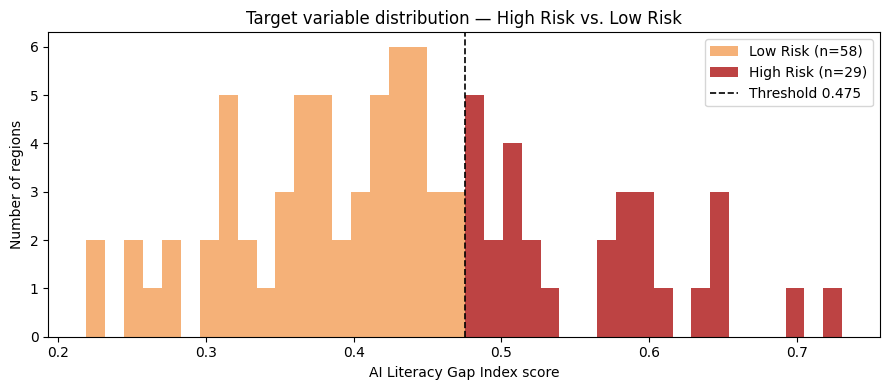

In [5]:
# -----------------------------
# Distribution of index scores with High Risk threshold
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 4))

low  = df[df["high_risk"] == 0]["ai_literacy_gap_index"]
high = df[df["high_risk"] == 1]["ai_literacy_gap_index"]

ax.hist(low,  bins=20, color="#f4a460", alpha=0.85, label="Low Risk (n=58)")
ax.hist(high, bins=20, color="#b22222", alpha=0.85, label="High Risk (n=29)")
ax.axvline(threshold, color="black", linewidth=1.2, linestyle="--", label=f"Threshold {threshold:.3f}")

ax.set_xlabel("AI Literacy Gap Index score")
ax.set_ylabel("Number of regions")
ax.set_title("Target variable distribution — High Risk vs. Low Risk")
ax.legend()
plt.tight_layout()
plt.show()

### Distribution — interpretation

The score distribution is continuous with no visible gap or natural break around the threshold. Three observations:

- **No natural cutoff:** The boundary between High Risk and Low Risk is a deliberate methodological choice (top third), not a data-driven cluster boundary. This is expected — the index is a continuous score, not a classification.
- **Moderate-risk concentration:** The majority of regions fall between 0.30 and 0.50, reflecting that most EU regions face gradual rather than acute structural risk.
- **Class balance:** 29 High Risk vs. 58 Low Risk (1:2 ratio) — a manageable imbalance for logistic regression. No resampling or class-weight correction is needed.

## Step 3: Feature matrix and NaN handling

The feature matrix consists of the six raw pillar values. P5 (`unemployment_rate_low_edu_pct`) is missing for 7 EU regions due to small LFS sample sizes — the same issue handled identically in `04_clustering.ipynb`. Following the decision documented in DOCUMENTATION.md Section 13.1, missing P5 values are imputed with the mean P5 of the other available NUTS-1 regions in the same country.

In [6]:
# -----------------------------
# Define feature columns
# -----------------------------
FEATURE_COLS = [
    "digital_skills_pct",
    "poverty_social_exclusion_rate",
    "low_education_pct",
    "lifelong_learning_pct",
    "unemployment_rate_low_edu_pct",
    "share_ge65_pct",
]

df_model = df.copy()

# -----------------------------
# Impute missing P5 with country-level mean (see DOCUMENTATION.md Section 13.1)
# -----------------------------
country_p5_mean = (
    df_model.groupby("country")["unemployment_rate_low_edu_pct"]
    .transform("mean")
)
df_model["unemployment_rate_low_edu_pct"] = df_model["unemployment_rate_low_edu_pct"].fillna(country_p5_mean)

imputed = df[df["unemployment_rate_low_edu_pct"].isna()][["geo", "country"]].copy()
imputed["imputed_value"] = imputed["country"].map(
    df.groupby("country")["unemployment_rate_low_edu_pct"].mean().round(2)
)
print("P5 imputed with country-level mean:")
display(imputed.reset_index(drop=True))
print(f"\nRegions in model: {len(df_model)}  |  High Risk: {df_model['high_risk'].sum()}  |  Low Risk: {(df_model['high_risk']==0).sum()}")

P5 imputed with country-level mean:


,geo,country,imputed_value
0,DE8,Germany,10.48
1,FRM,France,14.71
2,PL2,Poland,11.93
3,PL7,Poland,11.93
4,PL8,Poland,11.93
5,PL9,Poland,11.93
6,PT3,Portugal,6.15



Regions in model: 87  |  High Risk: 29  |  Low Risk: 58


## Step 4: Train / Test split, standardise, and fit model

The dataset is split 70 / 30 into training and test sets. Stratification on the target ensures the 1:2 class ratio (High / Low Risk) is preserved in both sets.

Features are standardised with `StandardScaler` (mean = 0, std = 1) so that coefficients are comparable across pillars regardless of their original range. The scaler is fitted on the **training set only** and then applied to the test set — both steps are wrapped in a `sklearn Pipeline` to prevent data leakage.

`LogisticRegression` is fitted with `max_iter=1000` to ensure convergence on this dataset size.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# -----------------------------
# Train / Test split — 70/30, stratified
# -----------------------------
X = df_model[FEATURE_COLS]
y = df_model["high_risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

print(f"Train: {len(X_train)} regions  |  High Risk: {y_train.sum()}  Low Risk: {(y_train==0).sum()}")
print(f"Test:  {len(X_test)} regions   |  High Risk: {y_test.sum()}   Low Risk: {(y_test==0).sum()}")

# -----------------------------
# Pipeline: StandardScaler + LogisticRegression
# -----------------------------
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(max_iter=1000, random_state=42)),
])

pipeline.fit(X_train, y_train)
print("\nModel fitted successfully.")

Train: 60 regions  |  High Risk: 20  Low Risk: 40
Test:  27 regions   |  High Risk: 9   Low Risk: 18

Model fitted successfully.


## Step 5: Evaluation

Two complementary evaluation approaches are used:

1. **Test set metrics** — Accuracy, Precision, Recall, and F1 on the held-out 27 regions. F1 is the primary metric because it balances precision and recall, which matters when the classes are unequal in size (29 vs. 58 regions).

2. **5-fold cross-validation** — With only 87 regions total, a single 70/30 split produces a test set of just 27 regions. Cross-validation repeatedly splits the full dataset into 5 folds, trains on 4 and evaluates on 1, giving a more stable performance estimate that is less dependent on one particular split.

Test set results (n=27)
Accuracy: 0.96

              precision    recall  f1-score   support

    Low Risk       0.95      1.00      0.97        18
   High Risk       1.00      0.89      0.94         9

    accuracy                           0.96        27
   macro avg       0.97      0.94      0.96        27
weighted avg       0.96      0.96      0.96        27



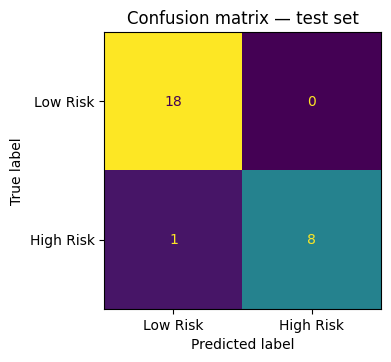

In [8]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score

# -----------------------------
# Test set metrics
# -----------------------------
y_pred = pipeline.predict(X_test)

print("Test set results (n=27)")
print("=" * 40)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print()
print(classification_report(y_test, y_pred, target_names=["Low Risk", "High Risk"]))

# -----------------------------
# Confusion matrix
# -----------------------------
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Low Risk", "High Risk"],
    colorbar=False,
    ax=ax,
)
ax.set_title("Confusion matrix — test set")
plt.tight_layout()
plt.show()

In [9]:
# -----------------------------
# 5-fold cross-validation
# -----------------------------
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring="f1")

print("5-fold cross-validation — F1 score")
print("=" * 40)
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.2f}")
print(f"\n  Mean F1: {cv_scores.mean():.2f}  (± {cv_scores.std():.2f})")

5-fold cross-validation — F1 score
  Fold 1: 0.83
  Fold 2: 0.91
  Fold 3: 1.00
  Fold 4: 0.67
  Fold 5: 1.00

  Mean F1: 0.88  (± 0.12)


## Step 6: Coefficient analysis — main risk drivers

The standardised logistic regression coefficients answer the core question: **which pillar most strongly separates High-Risk from Low-Risk regions?**

A larger absolute coefficient means stronger predictive power. The sign shows the direction: a positive coefficient means higher values predict High Risk; a negative coefficient means higher values predict Low Risk.

,rank,pillar,coefficient
0,1,P1 — Digital Skills,-2.09
1,2,P2 — Poverty,1.10
2,3,P5 — Unemployment,1.01
3,4,P4 — Lifelong Learning,-0.95
4,5,P3 — Low Education,0.89
5,6,P6 — Demographics,0.42


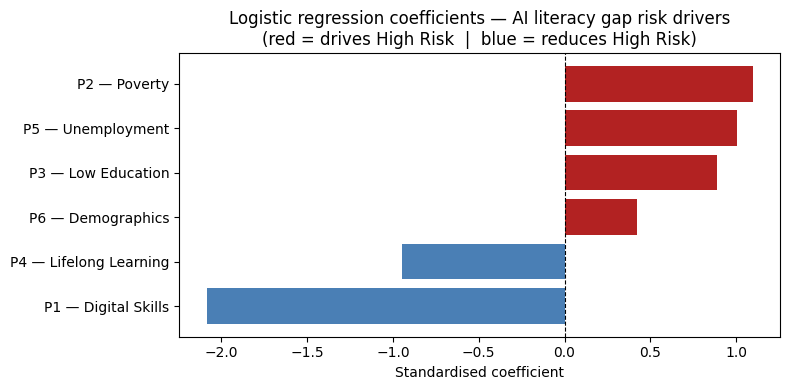

In [10]:
# -----------------------------
# Extract and rank coefficients
# -----------------------------
PILLAR_LABELS = {
    "digital_skills_pct":             "P1 — Digital Skills",
    "poverty_social_exclusion_rate":  "P2 — Poverty",
    "low_education_pct":              "P3 — Low Education",
    "lifelong_learning_pct":          "P4 — Lifelong Learning",
    "unemployment_rate_low_edu_pct":  "P5 — Unemployment",
    "share_ge65_pct":                 "P6 — Demographics",
}

coefs = pipeline["clf"].coef_[0]
coef_df = pd.DataFrame({
    "pillar":      [PILLAR_LABELS[c] for c in FEATURE_COLS],
    "coefficient": coefs,
    "abs":         abs(coefs),
}).sort_values("abs", ascending=False).reset_index(drop=True)

coef_df["rank"] = coef_df.index + 1
display(coef_df[["rank", "pillar", "coefficient"]].round(3))

# -----------------------------
# Coefficient bar chart
# -----------------------------
coef_plot = coef_df.sort_values("coefficient")
colors = ["#b22222" if c > 0 else "#4a7fb5" for c in coef_plot["coefficient"]]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(coef_plot["pillar"], coef_plot["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Standardised coefficient")
ax.set_title("Logistic regression coefficients — AI literacy gap risk drivers\n"
             "(red = drives High Risk  |  blue = reduces High Risk)")
plt.tight_layout()
plt.show()

### Findings

| Rank | Pillar | Coefficient | Interpretation |
|---|---|---|---|
| 1 | P1 — Digital Skills | −2.09 | **Dominant driver.** Coefficient is nearly twice the next strongest pillar. Lower digital skills → higher risk. |
| 2 | P2 — Poverty | +1.10 | |
| 3 | P5 — Unemployment | +1.01 | |
| 4 | P4 — Lifelong Learning | −0.95 | |
| 5 | P3 — Low Education | +0.89 | Ranks 2–5: coefficients span only 0.21 — no clear second lever, see note below. |
| 6 | P6 — Demographics | +0.42 | **Weakest driver** despite aging populations being most affected. See explanation below. |

---

**Finding 1 — P1 dominates with a magnitude that matters**

Digital skills (P1) is not merely the strongest driver — it is qualitatively in a different league. Its coefficient (−2.09) is nearly twice that of the next pillar (P2: 1.10). For a policymaker, this means: investing in digital competence has roughly double the risk-reduction leverage of any other intervention. The direction confirms intuition: regions with low digital skills rates consistently fall into the high-risk category.

**Finding 2 — No clear second lever**

Pillars P2 through P5 have coefficients between 0.89 and 1.10 — a range of only 0.21. With 87 observations, this difference is not statistically meaningful. The honest interpretation: poverty, unemployment, lifelong learning, and low education are **equally weak** as individual levers compared to digital skills. There is no single second priority — structural deprivation is multidimensional at this level.

**Finding 3 — Demographics (P6) is the weakest predictor: why this makes sense**

This finding initially appears to contradict the obvious: older people are more affected by AI literacy gaps. But the coefficient measures **discriminating power** — whether P6 separates high-risk from low-risk regions — not whether aging *matters* in absolute terms.

P6 is weak because of near-zero variance: as documented in `03_index_construction.ipynb`, 75 % of EU regions fall within a 3.9 percentage-point band (20–24 % share aged 65+). The EU ages uniformly — Bulgaria (high risk) and Sweden (low risk) both have ~21 % elderly population. Since the values barely differ across regions, the model cannot use P6 as a discriminator.

The policy implication is distinct: aging amplifies the AI literacy gap *within* every region, but it does not explain *why some regions are more at risk than others*. P6 is a universal pressure, not a differentiating factor.

## Step 7: Per-region contributions and export

For each region, we compute how much each pillar pushes it toward or away from the High Risk category. The contribution of pillar *i* for region *r* is:

```
contribution_i = coefficient_i × standardised_value_i
```

A positive contribution means the pillar pushes the region toward High Risk; a negative contribution means it reduces risk. The pillar with the largest absolute contribution is the **top driver** for that region.

This output is saved as `logistic_regression_contributions.csv` for the dashboard team — it provides the data behind the per-region tooltip.

In [11]:
import numpy as np

# -----------------------------
# Compute per-region pillar contributions
# -----------------------------
scaler = pipeline["scaler"]
coefs  = pipeline["clf"].coef_[0]

X_all_scaled  = scaler.transform(df_model[FEATURE_COLS])
contributions = X_all_scaled * coefs  # shape: (87, 6)

CONTRIB_COLS = [
    "contrib_P1_digital_skills",
    "contrib_P2_poverty",
    "contrib_P3_low_education",
    "contrib_P4_lifelong_learning",
    "contrib_P5_unemployment",
    "contrib_P6_demographics",
]

contrib_df = pd.DataFrame(contributions, columns=CONTRIB_COLS)

# -----------------------------
# Identify top driver per region (largest absolute contribution)
# -----------------------------
DRIVER_LABELS = {
    "contrib_P1_digital_skills":    "P1 — Digital Skills",
    "contrib_P2_poverty":           "P2 — Poverty",
    "contrib_P3_low_education":     "P3 — Low Education",
    "contrib_P4_lifelong_learning": "P4 — Lifelong Learning",
    "contrib_P5_unemployment":      "P5 — Unemployment",
    "contrib_P6_demographics":      "P6 — Demographics",
}

contrib_df["top_driver"] = (
    contrib_df[CONTRIB_COLS].abs().idxmax(axis=1).map(DRIVER_LABELS)
)

# -----------------------------
# Combine with region metadata
# -----------------------------
result = pd.concat([
    df_model[["geo", "nuts1_name", "country", "ai_literacy_gap_index", "cluster_label", "high_risk"]].reset_index(drop=True),
    contrib_df
], axis=1)

display(result[["geo", "nuts1_name", "high_risk", "top_driver"] + CONTRIB_COLS].head(10).round(3))

,geo,nuts1_name,high_risk,top_driver,contrib_P1_digital_skills,contrib_P2_poverty,contrib_P3_low_education,contrib_P4_lifelong_learning,contrib_P5_unemployment,contrib_P6_demographics
0,AT1,Ostösterreich,0,P1 — Digital Skills,-2.16,0.17,-0.20,-0.41,0.34,-0.42
1,AT2,Südösterreich,0,P1 — Digital Skills,-1.96,-0.12,-0.47,-0.19,-0.12,0.11
2,AT3,Westösterreich,0,P1 — Digital Skills,-1.85,-1.10,-0.31,-0.06,-0.60,-0.32
3,BE1,Région de Bruxelles-Capitale/Brussels Hoofdste...,0,P2 — Poverty,-1.23,2.59,0.11,-1.18,1.90,-1.39
4,BE2,Vlaams Gewest,0,P2 — Poverty,-0.54,-1.80,-0.36,-0.58,-0.36,-0.05
5,BE3,Région wallonne,0,P5 — Unemployment,-0.32,-0.10,0.19,-0.04,0.67,-0.30
6,BG3,Severna i Yugoiztochna Bulgaria,1,P1 — Digital Skills,3.90,2.42,-0.03,1.00,0.34,0.55
7,BG4,Yugozapadna i Yuzhna tsentralna Bulgaria,1,P1 — Digital Skills,2.89,0.99,-0.56,1.04,-0.87,0.08
8,CY0,Kýpros,0,P5 — Unemployment,0.39,-0.68,-0.30,0.28,-1.22,-0.58
9,CZ0,Česko,0,P1 — Digital Skills,-2.12,-1.78,-0.93,0.39,0.02,-0.20


In [12]:
# -----------------------------
# Top driver distribution across all regions
# -----------------------------
print("Top driver frequency across 87 EU NUTS-1 regions:")
display(result["top_driver"].value_counts().reset_index().rename(columns={"count": "regions"}))

# -----------------------------
# Export
# -----------------------------
out_path = PROCESSED_DIR / "logistic_regression_contributions.csv"
result.to_csv(out_path, index=False)
print(f"\nSaved: {out_path}")
print(f"Shape: {result.shape}")

Top driver frequency across 87 EU NUTS-1 regions:


,top_driver,regions
0,P1 — Digital Skills,48
1,P2 — Poverty,18
2,P4 — Lifelong Learning,7
3,P5 — Unemployment,6
4,P3 — Low Education,6
5,P6 — Demographics,2



Saved: /Users/joshuakehrer/code/JoshK00/ai-literacy-gap-index/AI-Literacy-Gap-Index/data/processed/logistic_regression_contributions.csv
Shape: (87, 13)


### Combined drivers — Top-2 analysis

Since ranks 2–5 cannot be individually distinguished, the more useful question is: **which two pillars most often act together as the primary risk drivers for a region?**

We derive the top-2 driver pair from the per-region contribution data already computed above. No new model is needed — this is a direct read from the contribution matrix.

Top-2 driver pair frequency across 87 EU NUTS-1 regions:


,driver_pair,regions
0,P1 — Digital Skills + P2 — Poverty,16
1,P1 — Digital Skills + P4 — Lifelong Learning,11
2,P1 — Digital Skills + P6 — Demographics,7
3,P1 — Digital Skills + P3 — Low Education,7
4,P1 — Digital Skills + P5 — Unemployment,7
5,P2 — Poverty + P3 — Low Education,7
6,P2 — Poverty + P1 — Digital Skills,5
7,P2 — Poverty + P5 — Unemployment,4
8,P4 — Lifelong Learning + P5 — Unemployment,4
9,P2 — Poverty + P4 — Lifelong Learning,2


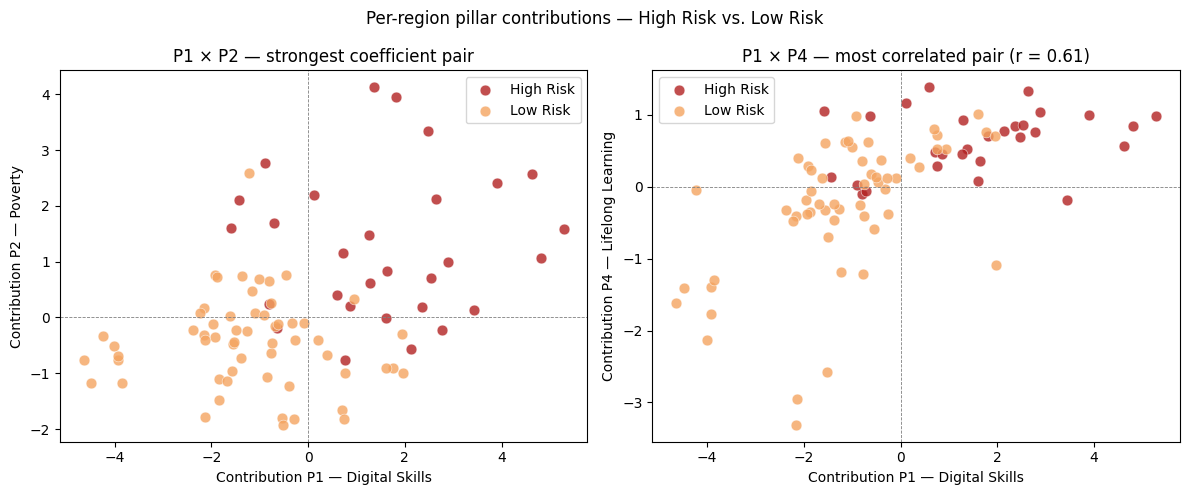

In [13]:
# -----------------------------
# Top-2 driver pairs per region
# -----------------------------
abs_contribs = result[CONTRIB_COLS].abs()

result["second_driver"] = (
    abs_contribs.apply(
        lambda row: row.nlargest(2).index[1], axis=1
    ).map(DRIVER_LABELS)
)

result["driver_pair"] = result["top_driver"] + "  +  " + result["second_driver"]

print("Top-2 driver pair frequency across 87 EU NUTS-1 regions:")
display(
    result["driver_pair"].value_counts()
    .reset_index()
    .rename(columns={"count": "regions"})
    .head(10)
)

# -----------------------------
# Scatter plot: P1 vs P2 — strongest coefficient pair, coloured by risk class
# -----------------------------
colors_risk = result["high_risk"].map({1: "#b22222", 0: "#f4a460"})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel 1: P1 vs P2 (rank 1 vs 2 by coefficient)
for risk, label, color in [(1, "High Risk", "#b22222"), (0, "Low Risk", "#f4a460")]:
    mask = result["high_risk"] == risk
    axes[0].scatter(
        result.loc[mask, "contrib_P1_digital_skills"],
        result.loc[mask, "contrib_P2_poverty"],
        c=color, label=label, alpha=0.8, edgecolors="white", linewidths=0.4, s=60
    )
axes[0].axhline(0, color="grey", linewidth=0.6, linestyle="--")
axes[0].axvline(0, color="grey", linewidth=0.6, linestyle="--")
axes[0].set_xlabel("Contribution P1 — Digital Skills")
axes[0].set_ylabel("Contribution P2 — Poverty")
axes[0].set_title("P1 × P2 — strongest coefficient pair")
axes[0].legend()

# Panel 2: P1 vs P4 — most correlated pair (r=0.61 from notebook 03)
for risk, label, color in [(1, "High Risk", "#b22222"), (0, "Low Risk", "#f4a460")]:
    mask = result["high_risk"] == risk
    axes[1].scatter(
        result.loc[mask, "contrib_P1_digital_skills"],
        result.loc[mask, "contrib_P4_lifelong_learning"],
        c=color, label=label, alpha=0.8, edgecolors="white", linewidths=0.4, s=60
    )
axes[1].axhline(0, color="grey", linewidth=0.6, linestyle="--")
axes[1].axvline(0, color="grey", linewidth=0.6, linestyle="--")
axes[1].set_xlabel("Contribution P1 — Digital Skills")
axes[1].set_ylabel("Contribution P4 — Lifelong Learning")
axes[1].set_title("P1 × P4 — most correlated pair (r = 0.61)")
axes[1].legend()

plt.suptitle("Per-region pillar contributions — High Risk vs. Low Risk", fontsize=12)
plt.tight_layout()
plt.show()

---

## Summary

This notebook trained a logistic regression classifier to identify which of the six structural vulnerability pillars most strongly predicts whether an EU NUTS-1 region falls into the high-risk category of the AI Literacy Gap Index.

### Methodology

| Decision | Choice | Rationale |
|---|---|---|
| Features | Raw pillar values (Eurostat %) | Independent from index normalisation |
| Target | Top third of `ai_literacy_gap_index` | Our final analytical product; PCA weights near-equal (14.8–18.4 %) |
| Standardisation | `StandardScaler` inside Pipeline | Coefficients comparable across pillars; prevents data leakage |
| Split | 70/30 stratified, `random_state=42` | Preserves 1:2 class ratio in both sets |
| NaN handling | Country-level mean imputation for P5 | Consistent with `04_clustering.ipynb` (DOCUMENTATION.md Section 13.1) |

### Model performance

| Metric | Value |
|---|---|
| Test set accuracy | 0.96 |
| Test set F1 (High Risk) | 0.94 |
| 5-fold CV mean F1 | 0.88 ± 0.12 |

### Key findings

**1. Digital Skills (P1) is the dominant driver** — coefficient −2.09, nearly twice the strength of any other pillar. 48 of 87 EU regions have P1 as their individual top driver.

**2. No clear second lever** — P2, P3, P4, P5 have coefficients between 0.89 and 1.10. Indistinguishable at n=87. Structural deprivation is multidimensional; no single second intervention point emerges.

**3. P1 + P2 is the most common driver pair** — 16 regions are primarily driven by the combination of low digital skills and high poverty. P1 + P4 follows with 11 regions.

**4. Demographics (P6) is the weakest predictor** — not because aging is irrelevant, but because the EU ages uniformly (IQR 3.9 pp). P6 is a universal pressure, not a regional differentiator.

**5. Data limitation identified** — age-specific digital skills (isoc_sk_dskl_i) exist at national level but were last updated in 2019, incompatible with the 2025 reference year. A country-level elderly digital skills proxy imputed to NUTS-1 regions would be a valid future enhancement.

### Output files

| File | Location | Content |
|---|---|---|
| `logistic_regression_contributions.csv` | `data/processed/` | Per-region pillar contributions + top driver + driver pair for dashboard tooltip |